In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import QAOAAnsatz
from qiskit.primitives import StatevectorEstimator as Estimator
from scipy.optimize import minimize
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
SEED = 42
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# Quantum Approximate Optimization Algorithm

The Quantum Approximate Optimization Algorithm (QAOA) was first proposed as a discretization of adiabatic quantum computing. Because in adiabatic quantum computing the Hamiltonian is countinuous and the gates in Quantum circuits are discrete, we use the Troteterization process to solve this problem. The continuous Hamiltonian is:

$$
H(t) = A(t)H_0 + B(t)H_1
$$

where $H_0$ is the initial Hamiltonian and $H_1$ is the final Hamiltonian, which encodes the optimization problem. The functions $A(t)$ and $B(t)$ with $t\in [0,T]$ control the evolution: at the beginning, $A(t)$ is large and $B(t)$ is close to zero, while at time $T$, $A(T)$ goes to zero and $B(T)$ becomes dominant.

By applying discretization, if the initial state is $|\psi_0\rangle$, then the final state can be approximated as a product of operators of the form:

$$
|\psi_f\rangle = \left (\prod_{m=0}^p e^{i\Delta t\left(A(t_m)H_0+B(t_m)H_1\right )} \right )|\psi_0\rangle
$$

where $t_m = m\frac{\Delta}{t}$ and $p=\frac{T}{\Delta t}$.

Unfortunately, the identity $e^{a+b}=e^ae^b$ where $a$ and $b$ are real numbers, doesn't hold, in general, for exponentials of matrixes (unless they conmute). But if $\Delta t$ is small, we can use the Lie-Trotter formula:

$$
e^{i\Delta t(A(t)H_0+B(t)H_1)} \approx e^{i\Delta tA(t)H_0} e^{i\Delta t B(t)H_1}
$$

Thus, the state of the adiabatic evolution can be expressed as:

$$
|\psi_f\rangle \approx \prod_{m=0}^p e^{i\Delta tA(t_m)H_0} e^{i\Delta t B(t_m)H_1}|\psi_0\rangle
$$

Inspired by this approximation, the QAOA is built by taking an initial state $|\psi_0\rangle$ and alternate for $p$ times the application of the operators $e^{i\gamma H_M}$ and $e^{i\beta H_C}$, where $H_M$ is the mixing Hamiltonian, $H_C$ is the cost Hamiltonian and $\gamma$ and $\beta$ are real numbers, which we will use as parameters for our optimization process. That way, we will build a quantum circuit to prepare the state:

$$
e^{i\beta_p H_0} e^{i\gamma_p H_1} \cdots e^{i\beta_2 H_0} e^{i\gamma_2 H_1} e^{i\beta_1 H_0} e^{i\gamma_1 H_1} |\psi_0\rangle
$$

We can goup the coefficients in tuples $\beta = (\beta_1,...,\beta_p)$ and $\gamma = (\gamma_1,...\gamma_p)$ and denote the whole state by $|\gamma ,\beta \rangle$.

Because our objetive is to find the ground state og $H_1$, we can use a clasical optimizer to find the values of $\beta$ and $\gamma$ that minimize:

$$
E(\beta ,\gamma) =  \langle \beta , \gamma | H_1 | \beta , \gamma \rangle
$$

Notice that the QAOA is a hybrid algorithm: we use classical computing for the minimizing process and quantum computing to estimate the value of $E(\beta ,\gamma)$. Once the optimal values $\beta^*$ and $\gamma^*$ are found, we use the quantum computer to prepare the state $|\gamma^* ,\beta^* \rangle$ and measure it. If the algorithm works correctly, the final state should have a big overlap with the ground state of $H_1$, so the results of the measurement will be very likely to represent a optimal (or close to optimal) solution of our original problem.

As in quantum annealing, for the mixing  (initial) Hamiltonian, we usually take:

$$
H_M = -\sum_{j=0}^{n-1}X_j
$$

whose ground state is:

$$
|\psi_0\rangle = |+\rangle ^{\otimes n}
$$

It is important to note that the choice of $H_M$ is not fixed, and in some cases it can be advantageous to adapt it to the specific problem we are trying to solve.

The cost (final) Hamiltonian is an Ising Hamiltonian of the form:

$$
H_C = -\sum_{j,k}J_{jk}Z_jZ_k -\sum_j h_j Z_j
$$

where $J_{jk}$ and $h_j$ are real numbers.


# Circuit Implementation

To implement QAOA, we need to learn how to implement two types of operators. In this case, we use the $Z$ operator, but the implementation is analogous for the other Pauli matrices, using their corresponding rotation gates.

To implement operations of the form:

$$
e^{-i\beta Z_i}
$$

we notice that this has the same form as a single-qubit rotation around the $Z$ axis:

$$
R_Z(\theta)=e^{-i\frac{\theta}{2}Z}
$$

Therefore, by choosing $\theta=2\beta$, we obtain:

$$
e^{-i\beta Z_i}=R_Z(2\beta)
$$

so we only need to apply an $R_Z(2\beta)$ gate to qubit $i$.

To implement operations of the form:

$$
e^{-i\beta Z_iZ_j}
$$

we need to apply a two-qubit phase depending on the parity of the two qubits. If $Z_i$ and $Z_j$ have the same value, then:

$$
e^{-i\beta Z_iZ_j} = e^{-i\beta}
$$

whereas if they have different values, then:

$$
e^{-i\beta Z_iZ_j} = e^{i\beta}
$$

This operation can be implemented using two CNOT gates and one $R_Z$ rotation. The first CNOT maps the parity of the two qubits onto the target qubit. Then, an $R_Z(2\beta)$ rotation is applied to introduce the required phase. Finally, the second CNOT uncomputes the parity and restores the original computational basis states.

Therefore, the circuit implementation is:

$$
\text{CNOT}_{i,j} \; R_Z(2\beta)_j \; \text{CNOT}_{i,j}
$$

This sequence implements the operator $e^{-i\beta Z_iZ_j}$ up to a global phase, which does not affect the measurement probabilities.

Now, let's use QAOA to solve the same optimization problems that we solved using quantum annealing in the previous notebook. To easily implement the algorithm, can import the `QAOAAnsatz` from `qiskit.circuit.library`. This will allow us to compare both approaches and see how the same cost Hamiltonians can be addressed with a gate-based quantum algorithm.

# Max-Cut problem

The Max-Cut problem is a classical optimization problem defined on a graph. Given a graph with vertices and edges, the goal is to divide the vertices into two different groups in such a way that the number of edges connecting vertices from different groups is maximized. In other words, we want to find the partition of the graph that “cuts” as many edges as possible.

The Max-Cut problem can be naturally formulated as a cost Hamiltonian for QAOA. Given a graph, we assign one qubit to each vertex. When the circuit is measured in the computational basis, each bit determines the group to which the corresponding vertex belongs. Therefore, two vertices are in different groups when their measured values are different.

For an edge $(i,j)$, the operator $Z_iZ_j$ has eigenvalue $+1$ when both qubits are in the same computational state, and eigenvalue $-1$ when they are in different computational states. Since Max-Cut tries to maximize the number of edges connecting different groups, we want to favor configurations where $Z_iZ_j$ contributes with eigenvalue $-1$. This can be done by minimizing the following cost Hamiltonian:

$$
H_C = \sum_{(i,j)\in E} Z_i Z_j
$$

where $E$ is the set of edges. 

In [ ]:
# Define the graph for the Max-Cut problem
nodes = ["A", "B", "C", "D", "E", "F"]

n = len(nodes)

edges = [
    ("A", "B"),
    ("A", "C"),
    ("A", "E"),
    ("B", "D"),
    ("B", "E"),
    ("C", "D"),
    ("C", "E"),
    ("D", "E"),
    ("D", "F"),
    ("E", "F")
]

# Parameters and method for the QAOA
n_reps_qaoa = 2
n_shots = 1024
max_iter = 200
method = "Nelder-Mead"

In [4]:
# Dictionaries to map nodes to qubits and vice versa
node_to_qubit = {node: i for i, node in enumerate(nodes)}
qubit_to_node = {value: key for key, value in node_to_qubit.items()}

# Define the cost operator
cost_operator = SparsePauliOp.from_sparse_list(
    [("ZZ",  [node_to_qubit[u], node_to_qubit[v]], 1.0) for u, v in edges],
    num_qubits=n
)

print(cost_operator)

SparsePauliOp(['IIIIZZ', 'IIIZIZ', 'IZIIIZ', 'IIZIZI', 'IZIIZI', 'IIZZII', 'IZIZII', 'IZZIII', 'ZIZIII', 'ZZIIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j])


In [5]:
# Define the mixer operator
mixer_operator = SparsePauliOp.from_sparse_list(
    [("X", [j], -1.0) for j in range(n)],
    num_qubits=n
)

print(mixer_operator)

SparsePauliOp(['IIIIIX', 'IIIIXI', 'IIIXII', 'IIXIII', 'IXIIII', 'XIIIII'],
              coeffs=[-1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j])


In [6]:
# Prepare the initial state 
initial_state = QuantumCircuit(n)
initial_state.h(range(n))
sv_init = Statevector.from_instruction(initial_state)
sv_init.draw("latex")

<IPython.core.display.Latex object>

In [7]:
def cost_function(params: list, ansatz, hamiltonian, estimator, cost_history):
    """
    Evaluates the cost function for the given ansatz and cost operator using estimation of the expectation value
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
    
    cost_history.append(float(cost))

    return float(cost)

In [8]:
np.random.seed(SEED)
cost_history = []

# Build the ansatz and initial parameters
qaoa_ansatz = QAOAAnsatz(initial_state=initial_state, mixer_operator=mixer_operator, cost_operator=cost_operator, reps=n_reps_qaoa)
x0 = np.random.rand(qaoa_ansatz.num_parameters) * 2 * np.pi

# Define the estimator
estimator = Estimator()

# Minimize the cost function
result = minimize(
    cost_function,
    x0,
    args=(qaoa_ansatz, cost_operator, estimator, cost_history),
    method=method,
    options={"maxiter": max_iter, "disp": False},
)

e:\mario\Proyectos\Quantum-Computing-Notebooks\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
e:\mario\Proyectos\Quantum-Computing-Notebooks\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
e:\mario\Proyectos\Quantum-Computing-Notebooks\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [9]:
def plot_cost_history(cost_history: list[float], reps: int) -> None:
    """
    Plot the cost value at each QAOA optimization iteration given the cost history.
    """
    # Plot the cost history
    plt.figure(figsize=(8, 5))
    plt.plot(cost_history, '-', color='teal', linewidth=2, markersize=5)
    plt.title(f"Evolution of the cost ({reps} repetitions)", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("$<H_C>$", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot the minimum cost found during the optimization
    min_cost = min(cost_history)
    min_iter = cost_history.index(min_cost)
    plt.scatter(min_iter, min_cost, color='red', s=40, zorder=5, label=f'Minimum: {min_cost:.2f}')
    plt.legend()

    plt.show()

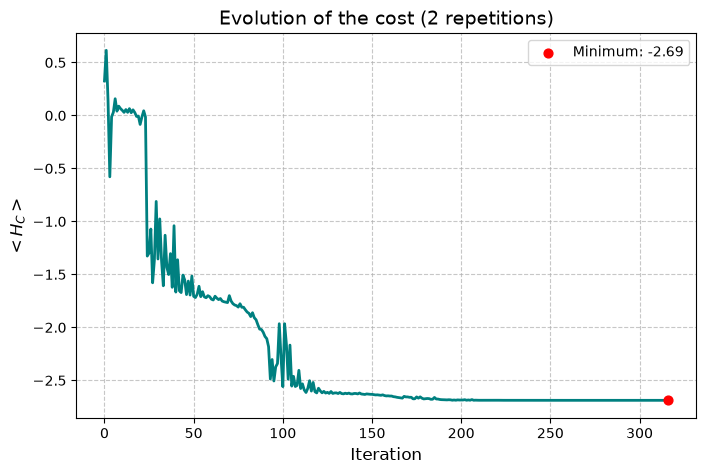

In [10]:
plot_cost_history(cost_history, n_reps_qaoa)

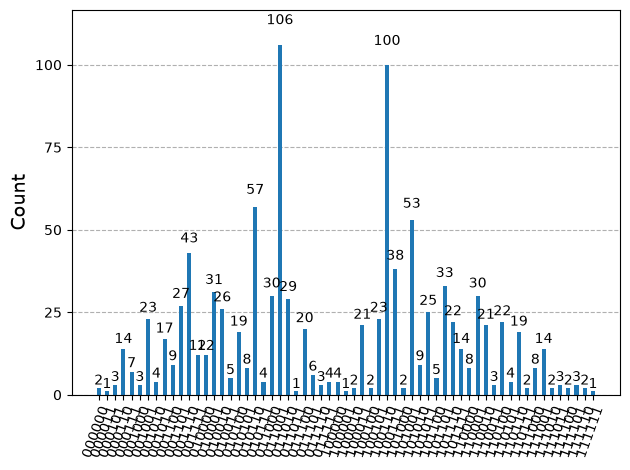

In [11]:
# Assign the optimized parameters to the ansatz
final_circuit = qaoa_ansatz.assign_parameters(result.x)

# Add measurement at the end of the circuit
final_circuit.measure_all()

# Transpile the circuit for the simulator
compiled_circuit = transpile(final_circuit, backend)

# Run the simulation
job = sampler.run([compiled_circuit], shots=n_shots)
result = job.result()[0].data.meas

# Get the counts and plot the histogram
counts = result.get_counts()
plot_histogram(counts)

In [12]:
def state_to_nodes(state: str, edges: list[tuple[str, str]], qubit_to_node: dict[int, str]) -> tuple[list[str], list[str], int]:
    """
    Convert a binary state into two groups of nodes and count the cuts.
    """
    group_0 = []
    group_1 = []

    for qubit, value in enumerate(state[::-1]):  # Reverse the state string to match qubit order
        node = qubit_to_node[qubit]

        if value == "0":
            group_0.append(node)
        else:
            group_1.append(node)

    cuts = sum(1 for u, v in edges if (u in group_0 and v in group_1) or (u in group_1 and v in group_0))

    return group_0, group_1, cuts

In [13]:
sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
for i in range(5):
    print(30 * "#")
    print("Solution number", i + 1)
    print(sorted_counts[i])
    group1, group2, cuts = state_to_nodes(sorted_counts[i][0], edges, qubit_to_node)
    print("Group 1:", group1)
    print("Group 2:", group2)
    print("Cuts:", cuts)
print(30 * "#")

##############################
Solution number 1
('011001', 106)
Group 1: ['B', 'C', 'F']
Group 2: ['A', 'D', 'E']
Cuts: 8
##############################
Solution number 2
('100110', 100)
Group 1: ['A', 'D', 'E']
Group 2: ['B', 'C', 'F']
Cuts: 8
##############################
Solution number 3
('010110', 57)
Group 1: ['A', 'D', 'F']
Group 2: ['B', 'C', 'E']
Cuts: 7
##############################
Solution number 4
('101001', 53)
Group 1: ['B', 'C', 'E']
Group 2: ['A', 'D', 'F']
Cuts: 7
##############################
Solution number 5
('001110', 43)
Group 1: ['A', 'E', 'F']
Group 2: ['B', 'C', 'D']
Cuts: 6
##############################


In [14]:
def compute_cut_success_rate(counts: dict[str, int], edges: list[tuple[str, str]], qubit_to_node: dict[int, str], n_cuts: int , n_shots: int) -> float:
    """
    Count the number of correct solutions and return the percentage.
    """
    n_correct = 0

    for state_str, count in counts.items():
        _, _, cuts = state_to_nodes(state_str, edges, qubit_to_node)
        if cuts == n_cuts:  # Maximum cuts for this graph
            n_correct += count

    return (n_correct/n_shots) * 100

In [15]:
percentage_8_cuts = compute_cut_success_rate(counts, edges, qubit_to_node, 8, n_shots)
print(f"Percentage of correct solutions: {percentage_8_cuts:2f} %")

Percentage of correct solutions: 20.1171875 %


The QAOA results show that the most frequent solutions achieve a cut value of 8 (around a 20%). These solutions correspond to the same partition up to a global exchange of the two groups, which means that QAOA is correctly identifying the best Max-Cut configuration for this graph.

Compared with the simulated annealing results, QAOA also finds the optimal partition, but the output is probabilistic and several suboptimal solutions still appear with lower frequency. This is expected, since QAOA depends on the chosen circuit depth, the optimized parameters and the sampling process.

We can study how the number of repetitions in the QAOA affect the quality of the result.

In [16]:
# Run the QAOA for different numbers of repetitions and store the results
reps_list = [1, 2, 3, 4]
cost_history_list = []
results_list = []
ansatz_list = []

np.random.seed(SEED)

for reps in reps_list:
    # Create a new random number generator for each repetition to ensure reproducibility
    rng = np.random.default_rng(SEED + reps)
    # Build the ansatz
    qaoa_ansatz = QAOAAnsatz(initial_state=initial_state, mixer_operator=mixer_operator, cost_operator=cost_operator, reps=reps)

    x0 = rng.uniform(0, 2*np.pi, qaoa_ansatz.num_parameters)
    
    cost_history = []
    
    # Minimize the cost function
    result = minimize(
        cost_function,
        x0,
        args=(qaoa_ansatz, cost_operator, estimator, cost_history),
        method=method,
        options={"maxiter": max_iter, "disp": False},
    )
    ansatz_list.append(qaoa_ansatz)
    results_list.append(result)
    cost_history_list.append(cost_history)

e:\mario\Proyectos\Quantum-Computing-Notebooks\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
e:\mario\Proyectos\Quantum-Computing-Notebooks\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
e:\mario\Proyectos\Quantum-Computing-Notebooks\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


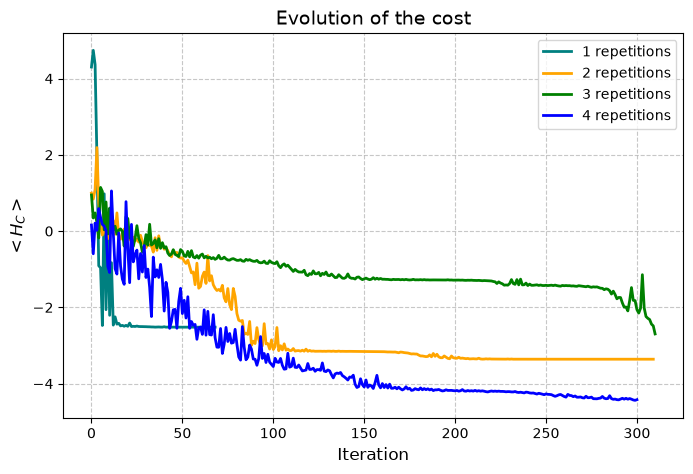

In [17]:
# Plot the cost histories for different repetitions
colors = ['teal', 'orange', 'green', 'blue', 'purple']
plt.figure(figsize=(8, 5))
for i, (cost_history, reps) in enumerate(zip(cost_history_list, reps_list)):
    plt.plot(cost_history, '-', color=colors[i], linewidth=2, markersize=5, label=f'{reps} repetitions')
plt.title("Evolution of the cost", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("$<H_C>$", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

##############################
Histogram for 1 repetitions:
Percentage of correct solutions: 16.41%
##############################


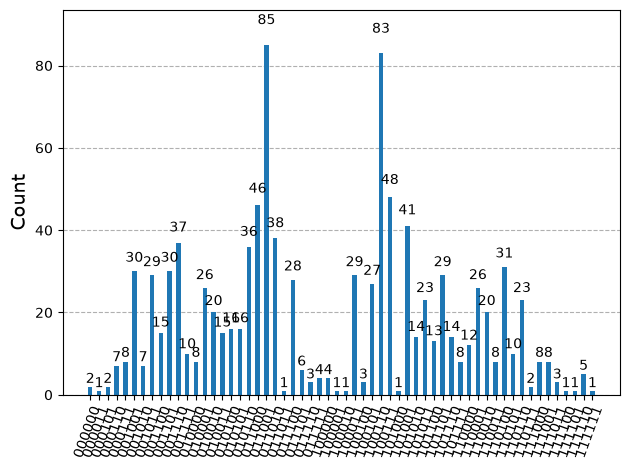

##############################
Histogram for 2 repetitions:
Percentage of correct solutions: 29.69%
##############################


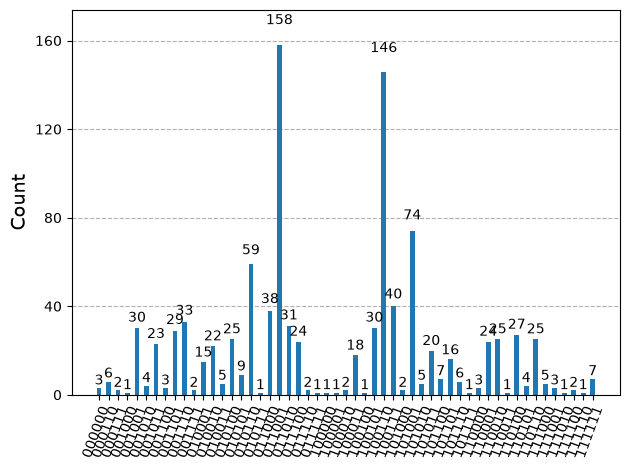

##############################
Histogram for 3 repetitions:
Percentage of correct solutions: 27.93%
##############################


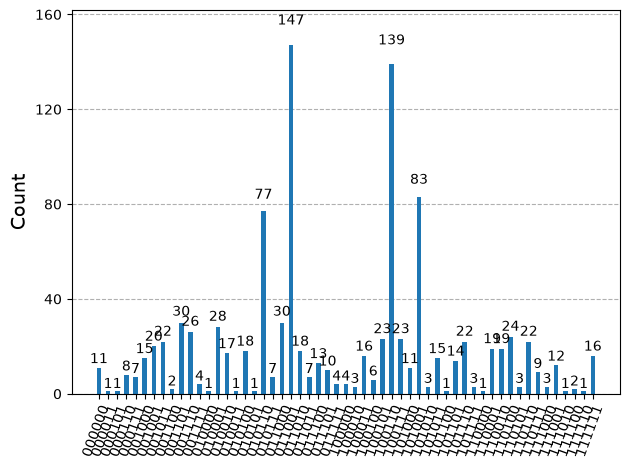

##############################
Histogram for 4 repetitions:
Percentage of correct solutions: 53.81%
##############################


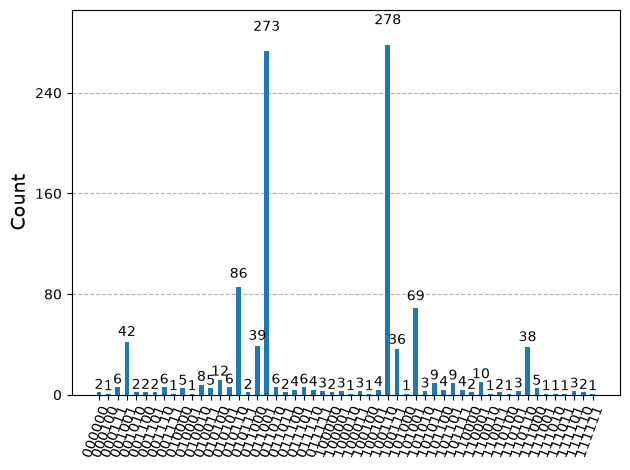

In [18]:
for i in range(len(reps_list)):
     # Assign the optimized parameters to the ansatz
    final_circuit = ansatz_list[i].assign_parameters(results_list[i].x)

    # Add measurement at the end of the circuit
    final_circuit.measure_all()

    # Transpile the circuit for the simulator
    compiled_circuit = transpile(final_circuit, backend)

    # Run the simulation and get the counts
    job = sampler.run([compiled_circuit], shots=1024)
    result = job.result()[0].data.meas
    counts = result.get_counts()

    # Compute the percentage of correct solutions for 8 cuts 
    percentage_8_cuts = compute_cut_success_rate(counts, edges, qubit_to_node, 8, n_shots) 

    # Print the histogram and the percentage of correct solutions 
    print(30 * "#") 
    print(f"Histogram for {reps_list[i]} repetitions:")
    print(f"Percentage of correct solutions: {percentage_8_cuts:.2f}%")
    print(30 * "#") 
    display(plot_histogram(counts))

Although increasing the number of QAOA repetitions makes the ansatz more expressive, it also increases the dimension and complexity of the parameter space. As a consequence, the classical optimizer has to search over a more difficult landscape, where it is more likely to get trapped in local minima or flat regions. Therefore, a larger value of $p$ does not always guarantee a better result in a single optimization run. In practice, deeper QAOA circuits may require better initialization strategies, more iterations, or several independent optimization runs to take advantage of their additional expressivity. 

In this particular execution, the best result was obtained with the maximum depth possible, $p=4$, reaching a correct-solution percentage of $53,81\%$. However, the case $p=3$ performed worse than $p=2$, which shows that the improvement is not necessarily monotonic with the number of layers. This behavior is consistent with the fact that the final result depends not only on the depth of the circuit, but also on the initial parameters, number of iterations and on the performance of the classical optimization process.

# Travelling Salesman Problem

The Traveling Salesman Problem (TSP) is a classical optimization problem defined on a weighted graph. Given a set of cities and the distance between each pair of them, the goal is to find the shortest possible route that visits every city exactly once and returns to the starting point.

To formulate the TSP for QAOA, we assign one qubit to each binary decision variable. The variable $x_{i,t} \in \{0,1\}$ indicates whether city $i$ is visited at position $t$ in the route. Therefore, for $n$ cities, this formulation requires $n^2$ qubits.

The cost of the route can be written as:

$$
H_{C}(x) = \sum_{t=0}^{n-1}\sum_{i\neq j} d_{i,j}x_{i,t}x_{j,t+1}
$$

where $d_{i,j}$ is the distance between cities $i$ and $j$, and $t+1$ is taken modulo $n$ so that the route returns to the starting city.

However, we also need to enforce two constraints: each city must be visited exactly once, and each position in the route must contain exactly one city. These constraints are added as penalty terms:

$$
H_{penalty}(x) =
\sum_i \left(\sum_t x_{i,t}-1\right)^2
+
\sum_t \left(\sum_i x_{i,t}-1\right)^2
$$

Therefore, the final cost function is:

$$
H(x) = H_{C}(x) + \lambda H_{penalty}(x)
$$

To implement this formulation in QAOA, the binary variables are converted into quantum operators. Since measuring a qubit in the computational basis gives values $0$ or $1$, each binary variable can be represented using the Pauli-$Z$ operator as:

$$
x_{i,t} = \frac{I - Z_{i,t}}{2}
$$

With this convention, the state $|0\rangle$ corresponds to $x_{i,t}=0$, and the state $|1\rangle$ corresponds to $x_{i,t}=1$.

The cost Hamiltonian becomes:

$$
H_{C}(Z) =
\sum_{t=0}^{n-1}\sum_{i,j} d_{i,j}
\left(\frac{I - Z_{i,t}}{2}\right)
\left(\frac{I - Z_{j,t+1}}{2}\right)
$$

or equivalently:

$$
H_{C}(Z) =
\frac{1}{4}
\sum_{t=0}^{n-1}\sum_{i,j} d_{i,j}
\left(I - Z_{i,t} - Z_{j,t+1} + Z_{i,t}Z_{j,t+1}\right)
$$

The constraints can be transformed in the same way:

$$
H_{penalty}(Z) =
\sum_i \left(\sum_t \frac{I - Z_{i,t}}{2}-1\right)^2
+
\sum_t \left(\sum_i \frac{I - Z_{i,t}}{2}-1\right)^2
$$

To expand these terms, we first consider a generic exactly-one constraint involving a set of qubits $Q$:

$$
\left(\sum_{q \in Q} x_q - 1\right)^2
$$

Using the fact that $x_q^2=x_q$ for binary variables, this becomes:

$$
\left(\sum_{q \in Q} x_q - 1\right)^2
=
2\sum_{q<r}x_qx_r-\sum_{q\in Q}x_q+1
$$

Now, using the transformation:

$$
x_q=\frac{I-Z_q}{2}
$$

we obtain:

$$
2x_qx_r =
\frac{1}{2}
\left(I-Z_q-Z_r+Z_qZ_r\right)
$$

and

$$
-x_q =
-\frac{I-Z_q}{2}
=
-\frac{1}{2}I+\frac{1}{2}Z_q
$$

Therefore, each exactly-one constraint can be written as:

$$
\left(\sum_{q \in Q} \frac{I-Z_q}{2}-1\right)^2
=
2\sum_{q<r}
\left(\frac{I-Z_q}{2}\right)
\left(\frac{I-Z_r}{2}\right)
-
\sum_{q\in Q}
\left(\frac{I-Z_q}{2}\right)
+1
$$

or equivalently:

$$
=
\frac{1}{2}\sum_{q<r}
\left(I-Z_q-Z_r+Z_qZ_r\right)
-
\frac{1}{2}\sum_{q\in Q}
\left(I-Z_q\right)
+1
$$

Thus, for the TSP constraints, the expanded penalty Hamiltonian is:

$$
H_{penalty}(Z)
=
\sum_i
\left[
\frac{1}{2}\sum_{t<t'}
\left(I-Z_{i,t}-Z_{i,t'}+Z_{i,t}Z_{i,t'}\right)
-
\frac{1}{2}\sum_t
\left(I-Z_{i,t}\right)
+1
\right]
$$

$$
+
\sum_t
\left[
\frac{1}{2}\sum_{i<i'}
\left(I-Z_{i,t}-Z_{i',t}+Z_{i,t}Z_{i',t}\right)
-
\frac{1}{2}\sum_i
\left(I-Z_{i,t}\right)
+1
\right]
$$

This expansion shows that the penalty Hamiltonian only contains constant terms, single-qubit $Z$ terms, and two-qubit $ZZ$ terms, so it can be directly implemented as a `SparsePauliOp`. Note that we can ignore all the offset terms in the optimization problem since they doesn't have any influence in the result.

The number of qubits needed for this framework is $n_cities^2$, so if we run in a simulator we won't be able to solve big problems. For that reason we will now solve a TSP example with just 4 cities.

In [3]:
# Define the cities and distances between them
cities = ["A", "B", "C", "D"]

n_cities = len(cities)
time = range(n_cities)

dist = {
    "A": {"B": 4, "C": 2, "D": 7,},
    "B": {"A": 4, "C": 5, "D": 3,},
    "C": {"A": 2, "B": 5, "D": 4,},
    "D": {"A": 7, "B": 3, "C": 4,}
}

n_qubits = len(cities) * len(time)

In [4]:
# Parameters and method for the QAOA
n_reps_qaoa = 2
n_shots = 1024
max_iter = 50
method = "Nelder-Mead"

In [5]:
# Map all the possible values of x_i_t to qubits
edge_mapping = []

for city in cities:
    for t in time:
        edge_mapping.append((city, t))
    
df_map = pd.DataFrame(edge_mapping, columns=['City', 'Time'])
display(df_map)

,City,Time
0,A,0
1,A,1
2,A,2
3,A,3
4,B,0
5,B,1
6,B,2
7,B,3
8,C,0
9,C,1


In [6]:
# Define the cost operator. Now we have also consider the implementation of the restrictions.
def get_qubit(city: str, t: int) -> int:
    """
    Return the qubit index associated with city i at position t.
    """
    return df_map[(df_map["City"] == city) & (df_map["Time"] == t)].index[0]

# First add the distance cost for each pair of cities at each time step
pauli_terms = []
for origin in cities:
    for dest in cities:
            if origin != dest:
                for t in time:
                    q_origin  = get_qubit(origin, t)
                    q_dest  = get_qubit(dest, (t+1)%n_cities)
                    d = dist[origin][dest]
                    pauli_terms.append(("ZZ", [q_origin, q_dest], d / 4))
                    pauli_terms.append(("Z", [q_origin], -d / 4))
                    pauli_terms.append(("Z", [q_dest], -d / 4))

lamb = 100 

# Each city is visited exactly once constraint
for city in cities:
    for t in time:
        q_t = get_qubit(city, t)
        pauli_terms.append(("Z", [q_t], lamb / 2))
        for t_prime in range(t + 1, n_cities):  
            q_t_prime  = get_qubit(city, t_prime)
            pauli_terms.append(("ZZ", [q_t, q_t_prime], lamb / 2))
            pauli_terms.append(("Z", [q_t], -lamb / 2))
            pauli_terms.append(("Z", [q_t_prime], -lamb / 2))

# One city at each time step constraint
for t in time:
    for i in range(n_cities):
        city_i = cities[i]
        q_i = get_qubit(city_i, t)
        pauli_terms.append(("Z", [q_i], lamb / 2))
        for i_prime in range(i + 1, n_cities):
            city_i_prime = cities[i_prime]
            q_i_prime  = get_qubit(city_i_prime, t)
            pauli_terms.append(("ZZ", [q_i, q_i_prime], lamb / 2))
            pauli_terms.append(("Z", [q_i], -lamb / 2))
            pauli_terms.append(("Z", [q_i_prime], -lamb / 2))


# Define the cost operator as a SparsePauliOp from the sparse list
cost_operator = SparsePauliOp.from_sparse_list(
    pauli_terms,
    num_qubits=n_qubits
).simplify()

print(cost_operator)

SparsePauliOp(['IIIIIIIIIIZIIIIZ', 'IIIIIIIIIIIIIIIZ', 'IIIIIIIIIIZIIIII', 'IIIIIIIIIZIIIIZI', 'IIIIIIIIIIIIIIZI', 'IIIIIIIIIZIIIIII', 'IIIIIIIIZIIIIZII', 'IIIIIIIIIIIIIZII', 'IIIIIIIIZIIIIIII', 'IIIIIIIIIIIZZIII', 'IIIIIIIIIIIIZIII', 'IIIIIIIIIIIZIIII', 'IIIIIIZIIIIIIIIZ', 'IIIIIIZIIIIIIIII', 'IIIIIZIIIIIIIIZI', 'IIIIIZIIIIIIIIII', 'IIIIZIIIIIIIIZII', 'IIIIZIIIIIIIIIII', 'IIIIIIIZIIIIZIII', 'IIIIIIIZIIIIIIII', 'IIZIIIIIIIIIIIIZ', 'IIZIIIIIIIIIIIII', 'IZIIIIIIIIIIIIZI', 'IZIIIIIIIIIIIIII', 'ZIIIIIIIIIIIIZII', 'ZIIIIIIIIIIIIIII', 'IIIZIIIIIIIIZIII', 'IIIZIIIIIIIIIIII', 'IIIIIIIIIIIZIIZI', 'IIIIIIIIIIZIIZII', 'IIIIIIIIIZIIZIII', 'IIIIIIIIZIIIIIIZ', 'IIIIIIZIIIIZIIII', 'IIIIIZIIIIZIIIII', 'IIIIZIIIIZIIIIII', 'IIIIIIIZZIIIIIII', 'IIZIIIIIIIIZIIII', 'IZIIIIIIIIZIIIII', 'ZIIIIIIIIZIIIIII', 'IIIZIIIIZIIIIIII', 'IIIIIIIZIIIIIIZI', 'IIIIIIZIIIIIIZII', 'IIIIIZIIIIIIZIII', 'IIIIZIIIIIIIIIIZ', 'IIIIIIIZIIZIIIII', 'IIIIIIZIIZIIIIII', 'IIIIIZIIZIIIIIII', 'IIIIZIIIIIIZIIII', 'IIZIIIIZIIIIIIII', 'IZII

In [7]:
def cost_function(params: list, ansatz, hamiltonian, estimator, cost_history):
    """
    Evaluates the cost function for the given ansatz and cost operator using estimation of the expectation value
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
    
    cost_history.append(float(cost))

    return float(cost)

In this case, we will leave the default arguments for `initial_state` and `mixer_operator`, since they are exactly the ones we implemented before. We just did it for academical purposes, but it is not necesary .

In [ ]:
np.random.seed(SEED)

# Build the ansatz and initial parameters
qaoa_ansatz = QAOAAnsatz(cost_operator=cost_operator, reps=n_reps_qaoa)
x0 = np.random.rand(qaoa_ansatz.num_parameters) * 2 * np.pi

# Define the estimator
estimator = Estimator()

# Minimize the cost function
cost_history = []

result = minimize(
    cost_function,
    x0,
    args=(qaoa_ansatz, cost_operator, estimator, cost_history),
    method=method,
    options={"maxiter": max_iter, "disp": False},
)

e:\mario\Proyectos\Quantum-Computing-Notebooks\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
e:\mario\Proyectos\Quantum-Computing-Notebooks\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [ ]:
def plot_cost_history(cost_history: list[float], reps: int) -> None:
    """
    Plot the cost value at each QAOA optimization iteration given the cost history.
    """
    # Plot the cost history
    plt.figure(figsize=(8, 5))
    plt.plot(cost_history, '-', color='teal', linewidth=2, markersize=5)
    plt.title(f"Evolution of the cost ({reps} repetitions)", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("$<H_C>$", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot the minimum cost found during the optimization
    min_cost = min(cost_history)
    min_iter = cost_history.index(min_cost)
    plt.scatter(min_iter, min_cost, color='red', s=40, zorder=5, label=f'Minimum: {min_cost:.2f}')
    plt.legend()

    plt.show()

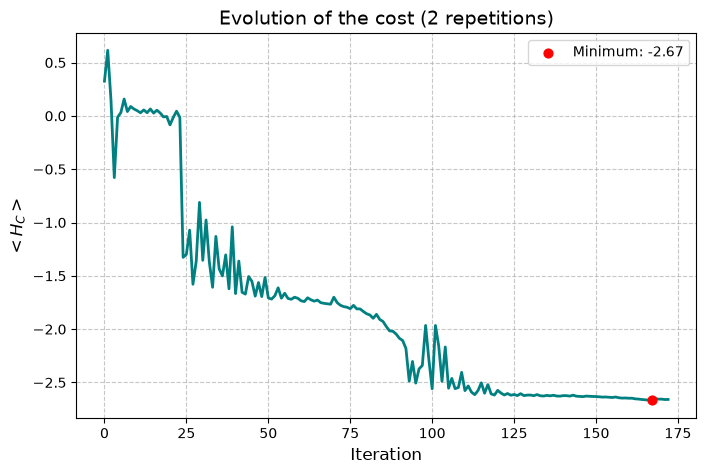

In [ ]:
plot_cost_history(cost_history, n_reps_qaoa)

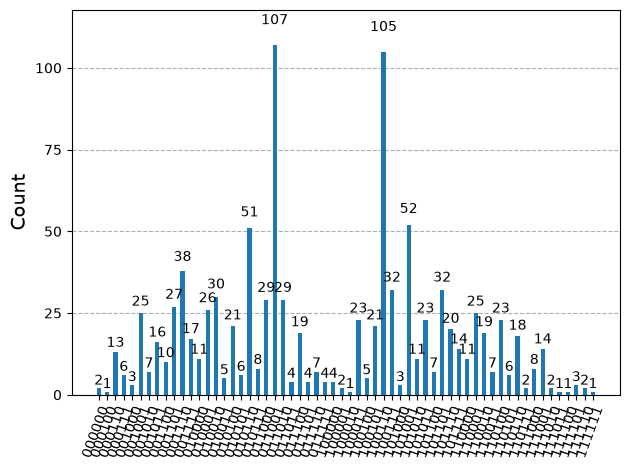

In [ ]:
# Assign the optimized parameters to the ansatz
final_circuit = qaoa_ansatz.assign_parameters(result.x)

# Add measurement at the end of the circuit
final_circuit.measure_all()

# Transpile the circuit for the simulator
compiled_circuit = transpile(final_circuit, backend)

# Run the simulation
job = sampler.run([compiled_circuit], shots=n_shots)
result = job.result()[0].data.meas

# Get the counts and plot the histogram
counts = result.get_counts()
plot_histogram(counts)

In [ ]:
def state_to_tour(state: str, df_map: pd.DataFrame) -> list[str]:
    """
    Convert a binary state into a tour of cities.
    """
    tour = [None] * len(df_map['Time'].unique())
    
    for qubit, value in enumerate(state[::-1]):  # Reverse the state string to match qubit order
        if value == "1":
            city = df_map.iloc[qubit]['City']
            time = df_map.iloc[qubit]['Time']
            tour[time] = city

    return "->".join(tour)

In [ ]:
sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
for i in range(5):
    print(30 * "#")
    print("Solution number", i + 1)
    print(sorted_counts[i])
    tour = state_to_tour(sorted_counts[i][0], df_map)
    print("Tour:", tour)
print(30 * "#")